# Stellar Channel Investigation

## Motivation

From our pasting investigation, we discovered that:
1. **VDM dramatically outperforms Interpolant** at generating all channels
2. Both models use the **same UNet backbone** - so what's different?
3. The **stellar channel is particularly challenging** due to sparsity (73% zeros in ground truth)

## Key Questions

1. **Why does VDM work better than Interpolant with the same architecture?**
   - VDM predicts noise (εθ) vs Interpolant predicts velocity (vθ)
   - VDM has focal loss for stellar channel
   - VDM uses variance-preserving diffusion with learned noise schedule
   
2. **What are the fundamental differences in stellar field representation?**
   - Ground truth: highly sparse, discrete point sources
   - Generated: smoother, more diffuse
   
3. **Can we improve stellar generation?**
   - Different loss functions (perceptual, adversarial)
   - Post-processing (sparsification)
   - Architecture changes (separate stellar head)

In [1]:
# Setup and imports
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from contextlib import redirect_stdout, redirect_stderr
import io

# Project paths
PROJECT_ROOT = Path('/mnt/home/mlee1/vdm_BIND')
sys.path.insert(0, str(PROJECT_ROOT))

# BIND imports
from bind.bind import BIND
from bind.config_loader import ConfigLoader
from bind.power_spec import compute_power_spectrum_simple
from vdm.io_utils import load_simulation, project_particles_2d, load_halo_catalog

# Plotting setup
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Suppress verbose output
import warnings
warnings.filterwarnings('ignore')

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Using device: cuda


## Configuration

Set up the simulation and model paths. We'll start with VDM and then compare to other models.

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Configuration
SIM_NUM = 0
SNAPNUM = 90

CAMELS_ROOT = Path('/mnt/ceph/users/camels/Sims')
DMO_PATH = CAMELS_ROOT / 'IllustrisTNG_DM' / 'L50n512' / 'CV' / f'CV_{SIM_NUM}'
HYDRO_PATH = CAMELS_ROOT / 'IllustrisTNG' / 'L50n512' / 'CV' / f'CV_{SIM_NUM}'

BOX_SIZE = 50000.0  # kpc/h
GRID_SIZE = 1024    # Resolution for voxelization
BOX_MPC = BOX_SIZE / 1000.0  # 50 Mpc/h
CUTOUT_SIZE_MPC = 6.25  # Mpc/h
MASS_THRESHOLD = 1e13  # M_sun/h

print(f"DMO: {DMO_PATH}")
print(f"Hydro: {HYDRO_PATH}")
print(f"Grid: {GRID_SIZE}^2, Pixel size: {BOX_MPC/GRID_SIZE:.4f} Mpc/h")

# Model configurations to compare
MODEL_CONFIGS = {
    'vdm': PROJECT_ROOT / 'configs/clean_vdm_regularized.ini',
    'interpolant': PROJECT_ROOT / 'configs/interpolant.ini',
    # Add more models as needed
}

# Primary model for detailed analysis
PRIMARY_MODEL = 'vdm'
config_path = str(MODEL_CONFIGS[PRIMARY_MODEL])

print(f"Simulation: CV_{SIM_NUM}")
print(f"Box: {BOX_MPC} Mpc/h, Grid: {GRID_SIZE}²")
print(f"Cutout: {CUTOUT_SIZE_MPC} Mpc/h")
print(f"Mass threshold: {MASS_THRESHOLD:.1e} M_sun/h")
print(f"\nPrimary model: {PRIMARY_MODEL}")
print(f"Config: {config_path}")

DMO: /mnt/ceph/users/camels/Sims/IllustrisTNG_DM/L50n512/CV/CV_0
Hydro: /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/CV/CV_0
Grid: 1024^2, Pixel size: 0.0488 Mpc/h
Simulation: CV_0
Box: 50.0 Mpc/h, Grid: 1024²
Cutout: 6.25 Mpc/h
Mass threshold: 1.0e+13 M_sun/h

Primary model: vdm
Config: /mnt/home/mlee1/vdm_BIND/configs/clean_vdm_regularized.ini


## Part 1: Understanding the Fundamental Problem

Before comparing models, let's understand what makes the stellar channel so difficult.

In [4]:
# Load ground truth stellar field for analysis
print("Loading simulation data...")
hydro_snapdir = str(HYDRO_PATH / f'snapdir_{SNAPNUM:03d}')

# Load particles
dm_pos, dm_mass, hydro_dm_pos, hydro_dm_mass, gas_pos, gas_mass, star_pos, star_mass = \
    load_simulation(str(DMO_PATH), hydro_snapdir, snapnum=SNAPNUM)

print(f"\nParticle counts:")
print(f"  DM (DMO): {len(dm_pos):,}")
print(f"  DM (Hydro): {len(hydro_dm_pos):,}")
print(f"  Gas: {len(gas_pos):,}")
print(f"  Stars: {len(star_pos):,}")

# Project to 2D
print("\nProjecting to 2D grids...")
star_field = project_particles_2d(star_pos, star_mass, box_size=BOX_MPC, resolution=GRID_SIZE, axis=2)
gas_field = project_particles_2d(gas_pos, gas_mass, box_size=BOX_MPC, resolution=GRID_SIZE, axis=2)
dm_field = project_particles_2d(hydro_dm_pos, hydro_dm_mass, box_size=BOX_MPC, resolution=GRID_SIZE, axis=2)

print(f"\nField statistics:")
print(f"  Stars: min={star_field.min():.2e}, max={star_field.max():.2e}, mean={star_field.mean():.2e}")
print(f"  Gas: min={gas_field.min():.2e}, max={gas_field.max():.2e}, mean={gas_field.mean():.2e}")
print(f"  DM: min={dm_field.min():.2e}, max={dm_field.max():.2e}, mean={dm_field.mean():.2e}")

Loading simulation data...

Particle counts:
  DM (DMO): 134,217,728
  DM (Hydro): 134,217,728
  Gas: 127,990,117
  Stars: 4,733,834

Projecting to 2D grids...

Field statistics:
  Stars: min=0.00e+00, max=2.68e+11, mean=4.16e+07
  Gas: min=1.22e+08, max=2.31e+11, mean=1.58e+09
  DM: min=4.64e+08, max=2.84e+12, mean=8.30e+09


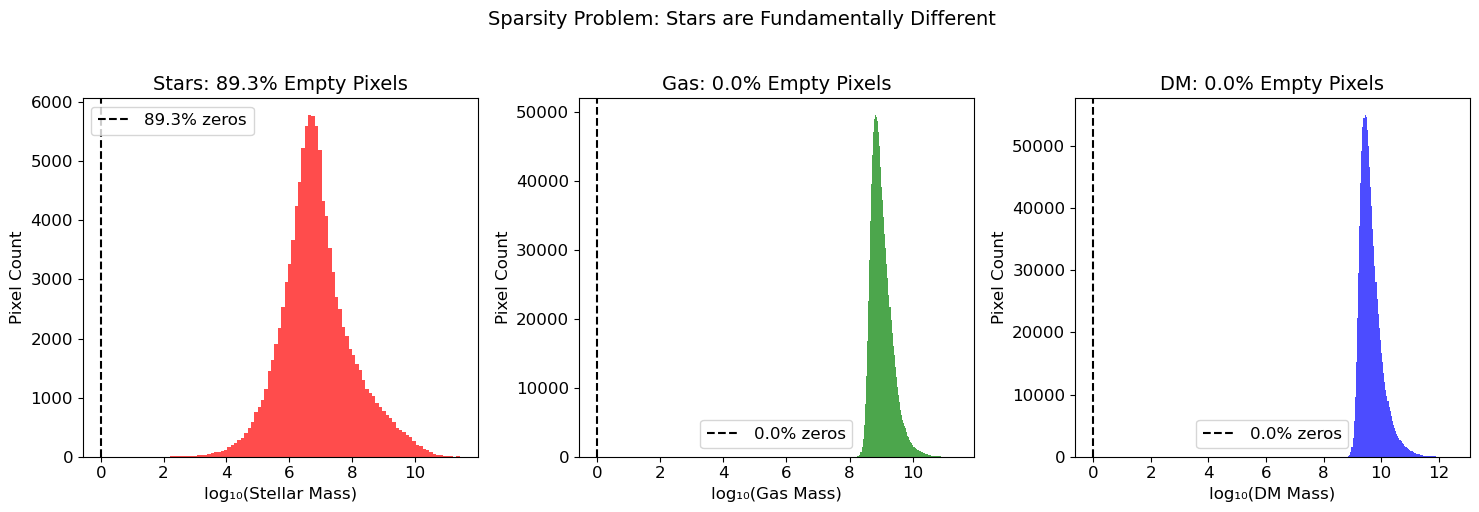


📊 SPARSITY SUMMARY:
  DM:    0.0% empty pixels (dense field)
  Gas:   0.0% empty pixels (moderately sparse)
  Stars: 89.3% empty pixels (HIGHLY SPARSE!)


In [5]:
# Analyze the sparsity problem
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Stars: extreme sparsity
ax = axes[0]
stars_flat = star_field.flatten()
zero_frac_stars = (stars_flat == 0).sum() / len(stars_flat) * 100
ax.hist(np.log10(stars_flat[stars_flat > 0] + 1e-10), bins=100, color='red', alpha=0.7)
ax.axvline(x=0, color='k', linestyle='--', label=f'{zero_frac_stars:.1f}% zeros')
ax.set_xlabel('log₁₀(Stellar Mass)')
ax.set_ylabel('Pixel Count')
ax.set_title(f'Stars: {zero_frac_stars:.1f}% Empty Pixels')
ax.legend()

# Gas: moderately sparse
ax = axes[1]
gas_flat = gas_field.flatten()
zero_frac_gas = (gas_flat == 0).sum() / len(gas_flat) * 100
ax.hist(np.log10(gas_flat[gas_flat > 0] + 1e-10), bins=100, color='green', alpha=0.7)
ax.axvline(x=0, color='k', linestyle='--', label=f'{zero_frac_gas:.1f}% zeros')
ax.set_xlabel('log₁₀(Gas Mass)')
ax.set_ylabel('Pixel Count')
ax.set_title(f'Gas: {zero_frac_gas:.1f}% Empty Pixels')
ax.legend()

# DM: dense
ax = axes[2]
dm_flat = dm_field.flatten()
zero_frac_dm = (dm_flat == 0).sum() / len(dm_flat) * 100
ax.hist(np.log10(dm_flat[dm_flat > 0] + 1e-10), bins=100, color='blue', alpha=0.7)
ax.axvline(x=0, color='k', linestyle='--', label=f'{zero_frac_dm:.1f}% zeros')
ax.set_xlabel('log₁₀(DM Mass)')
ax.set_ylabel('Pixel Count')
ax.set_title(f'DM: {zero_frac_dm:.1f}% Empty Pixels')
ax.legend()

plt.suptitle('Sparsity Problem: Stars are Fundamentally Different', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 SPARSITY SUMMARY:")
print(f"  DM:    {zero_frac_dm:.1f}% empty pixels (dense field)")
print(f"  Gas:   {zero_frac_gas:.1f}% empty pixels (moderately sparse)")
print(f"  Stars: {zero_frac_stars:.1f}% empty pixels (HIGHLY SPARSE!)")

### 1.1 Visualize the Difference: Stars vs Gas vs DM

The stellar field is fundamentally different from gas and DM:
- Stars are point sources (discrete particle positions)
- Gas is smoother (hydrodynamic processes diffuse it)
- DM is the densest (no feedback effects)

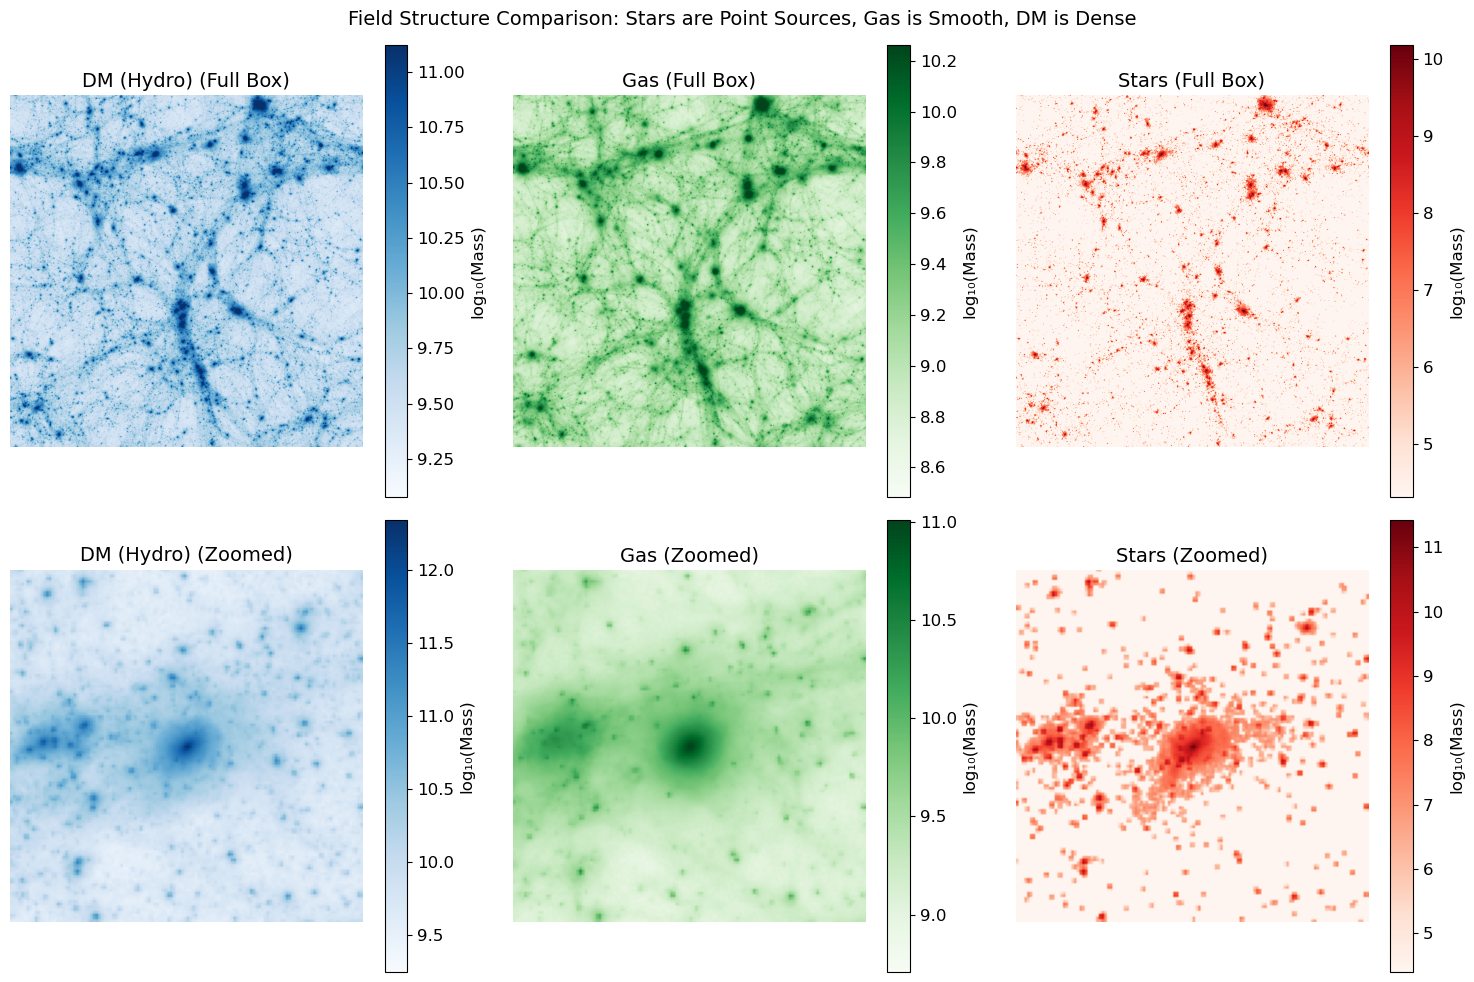

In [6]:
# Visual comparison of fields
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Full box view (top row)
for idx, (field, name, cmap) in enumerate([
    (dm_field, 'DM (Hydro)', 'Blues'),
    (gas_field, 'Gas', 'Greens'),
    (star_field, 'Stars', 'Reds')
]):
    ax = axes[0, idx]
    vmin = np.percentile(field[field > 0], 1) if (field > 0).any() else 1e-10
    vmax = np.percentile(field[field > 0], 99.5) if (field > 0).any() else 1
    im = ax.imshow(np.log10(field + vmin), cmap=cmap, vmin=np.log10(vmin), vmax=np.log10(vmax))
    ax.set_title(f'{name} (Full Box)')
    ax.axis('off')
    plt.colorbar(im, ax=ax, label='log₁₀(Mass)')

# Zoom into halo region (bottom row)
# Find a high-mass region
zoom_size = 128  # pixels
max_loc = np.unravel_index(np.argmax(star_field), star_field.shape)
y_start = max(0, max_loc[0] - zoom_size // 2)
x_start = max(0, max_loc[1] - zoom_size // 2)
y_end = min(GRID_SIZE, y_start + zoom_size)
x_end = min(GRID_SIZE, x_start + zoom_size)

for idx, (field, name, cmap) in enumerate([
    (dm_field, 'DM (Hydro)', 'Blues'),
    (gas_field, 'Gas', 'Greens'),
    (star_field, 'Stars', 'Reds')
]):
    ax = axes[1, idx]
    zoom = field[y_start:y_end, x_start:x_end]
    vmin = np.percentile(zoom[zoom > 0], 1) if (zoom > 0).any() else 1e-10
    vmax = zoom.max() if zoom.max() > 0 else 1
    im = ax.imshow(np.log10(zoom + vmin), cmap=cmap, vmin=np.log10(vmin), vmax=np.log10(vmax))
    ax.set_title(f'{name} (Zoomed)')
    ax.axis('off')
    plt.colorbar(im, ax=ax, label='log₁₀(Mass)')

plt.suptitle('Field Structure Comparison: Stars are Point Sources, Gas is Smooth, DM is Dense', fontsize=14)
plt.tight_layout()
plt.show()

## Part 2: Load VDM Model and Generate Samples

Now let's load the VDM model and generate samples for a few halos to analyze the stellar channel in detail.

In [9]:
# Load VDM model
import pandas as pd
from bind.model_manager import ModelManager
from bind.sampling import sample

print(f"Loading VDM model from: {config_path}")

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    config = ConfigLoader(config_path, verbose=False)
    
print(f"✓ Model loaded successfully")
print(f"  Checkpoint: {config.best_ckpt}")

Loading VDM model from: /mnt/home/mlee1/vdm_BIND/configs/clean_vdm_regularized.ini
✓ Model loaded successfully
  Checkpoint: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_regularized/version_0//checkpoints/epoch-epoch=189-step=121410.ckpt
✓ Model loaded successfully
  Checkpoint: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_regularized/version_0//checkpoints/epoch-epoch=189-step=121410.ckpt


In [10]:
# Initialize BIND with VDM model
print("Initializing BIND pipeline...")

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    bind = BIND(
        simulation_path=str(DMO_PATH),
        snapnum=SNAPNUM,
        boxsize=BOX_SIZE,
        gridsize=GRID_SIZE,
        config_path=config_path,
        dim='2d',
        axis=2,
        verbose=False,
        r_in_factor=2.0,
        r_out_factor=3.0,
        mass_threshold=MASS_THRESHOLD,
    )

# Voxelize and extract
print("Voxelizing simulation...")
bind.voxelize_simulation()

print("Extracting halos...")
bind.extract_halos(0.3, use_large_scale=True, num_large_scales=3)

n_halos = len(bind.extracted['metadata'])
print(f"\n✓ Extracted {n_halos} halos with M > {MASS_THRESHOLD:.1e} M_sun/h")

Initializing BIND pipeline...
Voxelizing simulation...
Voxelizing simulation...
Extracting halos...
Extracting halos...

✓ Extracted 45 halos with M > 1.0e+13 M_sun/h

✓ Extracted 45 halos with M > 1.0e+13 M_sun/h


In [11]:
# Get conditional params (fiducial cosmology)
metadata = pd.read_csv('/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')
base_params = list(metadata['FiducialVal'])
num_halos = len(bind.extracted['metadata'])
conditional_params = np.reshape(base_params * num_halos, (num_halos, -1))

# Generate halos
print(f"Generating {num_halos} halos with VDM...")
bind.generate_halos(batch_size=10, conditional_params=conditional_params, conserve_mass=True)

# Get generated halos
generated_halos = bind.generated_images
n_realizations = generated_halos[0].shape[0]

print(f"✓ Generated {len(generated_halos)} halos")
print(f"  Shape of each: {generated_halos[0].shape}")  # (n_realizations, n_channels, H, W)

Generating 45 halos with VDM...


Seed set to 8


✓ Scale-appropriate Fourier features enabled:
  - Halo (m_dm): High frequencies [1, 2, 4, 8]π -> 8 features per channel
  - Large-scale: Low frequencies [0.25, 0.5, 1, 2]π -> 8 features per channel
  - Target: No Fourier features (learns naturally)
  - Total input channels: 39
⚙️  ParamEmbedding: Conditional mode (n_params=35)
✓ Parameter conditioning enabled:
  - Time embedding dim: 384
  - Param embedding dim: 384
  - Total condition dim: 768
✓ Channel progression (encoder): [96, 192, 384, 768, 1024]
✓ Final decoder channels: 64 (GroupNorm groups: 8)
✓ Parameter predictor added (predicts 35 params)

INITIALIZING CLEAN VDM MODEL

📊 MODEL CONFIGURATION:
  Image shape: (3, 128, 128)
  Noise schedule: learned_nn
  Gamma range: [-13.3, 13.0]
  Data noise (per-channel): (0.001, 0.001, 0.001)
  Loss weights (diffusion, latent, recons): 1.0, 1.0, 1.0

🎯 CHANNEL WEIGHTS: (1, 1, 1)

✓ Parameter prediction enabled (weight=0.01)


✓ Final decoder channels: 64 (GroupNorm groups: 8)
✓ Parameter pr

Generating Samples (250 steps): 100%|██████████| 45/45 [05:25<00:00,  7.23s/it]


torch.Size([45, 10, 3, 128, 128])
✓ Generated 45 halos
  Shape of each: (10, 3, 128, 128)
✓ Generated 45 halos
  Shape of each: (10, 3, 128, 128)


In [22]:
# Helper function to extract 2D cutouts
def extract_cutout_2d(field, center_2d, cutout_size_mpc, box_mpc, grid_size):
    """Extract a cutout from a 2D field with periodic boundaries."""
    pix_size = box_mpc / grid_size
    cutout_pix = int(cutout_size_mpc / pix_size)
    half = cutout_pix // 2
    
    center_pix = (center_2d / box_mpc * grid_size).astype(int)
    
    y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % grid_size
    x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % grid_size
    
    return field[np.ix_(y_indices, x_indices)]

# Extract ground truth cutouts at halo locations
# Use ALL halos, not just 5
n_examples = num_halos  # Changed from min(5, num_halos)
gt_stars_cutouts = []
gt_gas_cutouts = []
gt_dm_cutouts = []
dmo_cutouts = []
halo_info = []

# Sort halos by mass to get most massive
halo_masses_list = [meta['mass'] for meta in bind.extracted['metadata']]
mass_order = np.argsort(halo_masses_list)[::-1]

print(f"Extracting GT cutouts for ALL {n_examples} halos...")
for i, idx in enumerate(mass_order[:n_examples]):
    meta = bind.extracted['metadata'][idx]
    pos_mpc = meta['position'] / 1000.0  # kpc -> Mpc
    center_2d = pos_mpc[:2]
    mass = meta['mass']
    
    gt_stars_cut = extract_cutout_2d(star_field, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    gt_gas_cut = extract_cutout_2d(gas_field, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    gt_dm_cut = extract_cutout_2d(dm_field, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    dmo_cut = extract_cutout_2d(bind.sim_grid, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    
    gt_stars_cutouts.append(gt_stars_cut)
    gt_gas_cutouts.append(gt_gas_cut)
    gt_dm_cutouts.append(gt_dm_cut)
    dmo_cutouts.append(dmo_cut)
    halo_info.append({'pos': pos_mpc, 'mass': mass, 'idx': idx})

print(f"  Mass range: {halo_info[-1]['mass']:.2e} - {halo_info[0]['mass']:.2e} M_sun/h")

gt_stars_cutouts = np.array(gt_stars_cutouts)
gt_gas_cutouts = np.array(gt_gas_cutouts)
gt_dm_cutouts = np.array(gt_dm_cutouts)
dmo_cutouts = np.array(dmo_cutouts)

Extracting GT cutouts for ALL 45 halos...
  Mass range: 1.00e+03 - 2.65e+04 M_sun/h


In [23]:
# Extract generated samples for the same halos (already denormalized by BIND)
# generated_halos has shape (n_realizations, n_channels, H, W) for each halo

gen_dm = []
gen_gas = []
gen_stars = []

for i, idx in enumerate(mass_order[:n_examples]):
    gen_halo = generated_halos[idx]  # (n_realizations, 3, H, W)
    
    # Channel order: [DM, Gas, Stars]
    gen_dm.append(gen_halo[:, 0, :, :])      # (n_real, H, W)
    gen_gas.append(gen_halo[:, 1, :, :])     # (n_real, H, W)
    gen_stars.append(gen_halo[:, 2, :, :])   # (n_real, H, W)

# Stack: (n_examples, n_realizations, H, W) -> transpose to (n_realizations, n_examples, H, W)
gen_dm = np.array(gen_dm).transpose(1, 0, 2, 3)
gen_gas = np.array(gen_gas).transpose(1, 0, 2, 3)
gen_stars = np.array(gen_stars).transpose(1, 0, 2, 3)

print(f"✓ Extracted generated samples")
print(f"  Shape: {gen_stars.shape} (n_realizations, n_halos, H, W)")
print(f"  DM range: [{gen_dm.min():.2e}, {gen_dm.max():.2e}]")
print(f"  Gas range: [{gen_gas.min():.2e}, {gen_gas.max():.2e}]")
print(f"  Stars range: [{gen_stars.min():.2e}, {gen_stars.max():.2e}]")

✓ Extracted generated samples
  Shape: (10, 45, 128, 128) (n_realizations, n_halos, H, W)
  DM range: [6.17e+08, 3.50e+12]
  Gas range: [1.84e+08, 3.64e+11]
  Stars range: [-1.19e-03, 2.46e+11]


## Part 3: Compare Generated vs Ground Truth Stellar Fields

Now let's analyze the differences between generated and ground truth stellar fields.

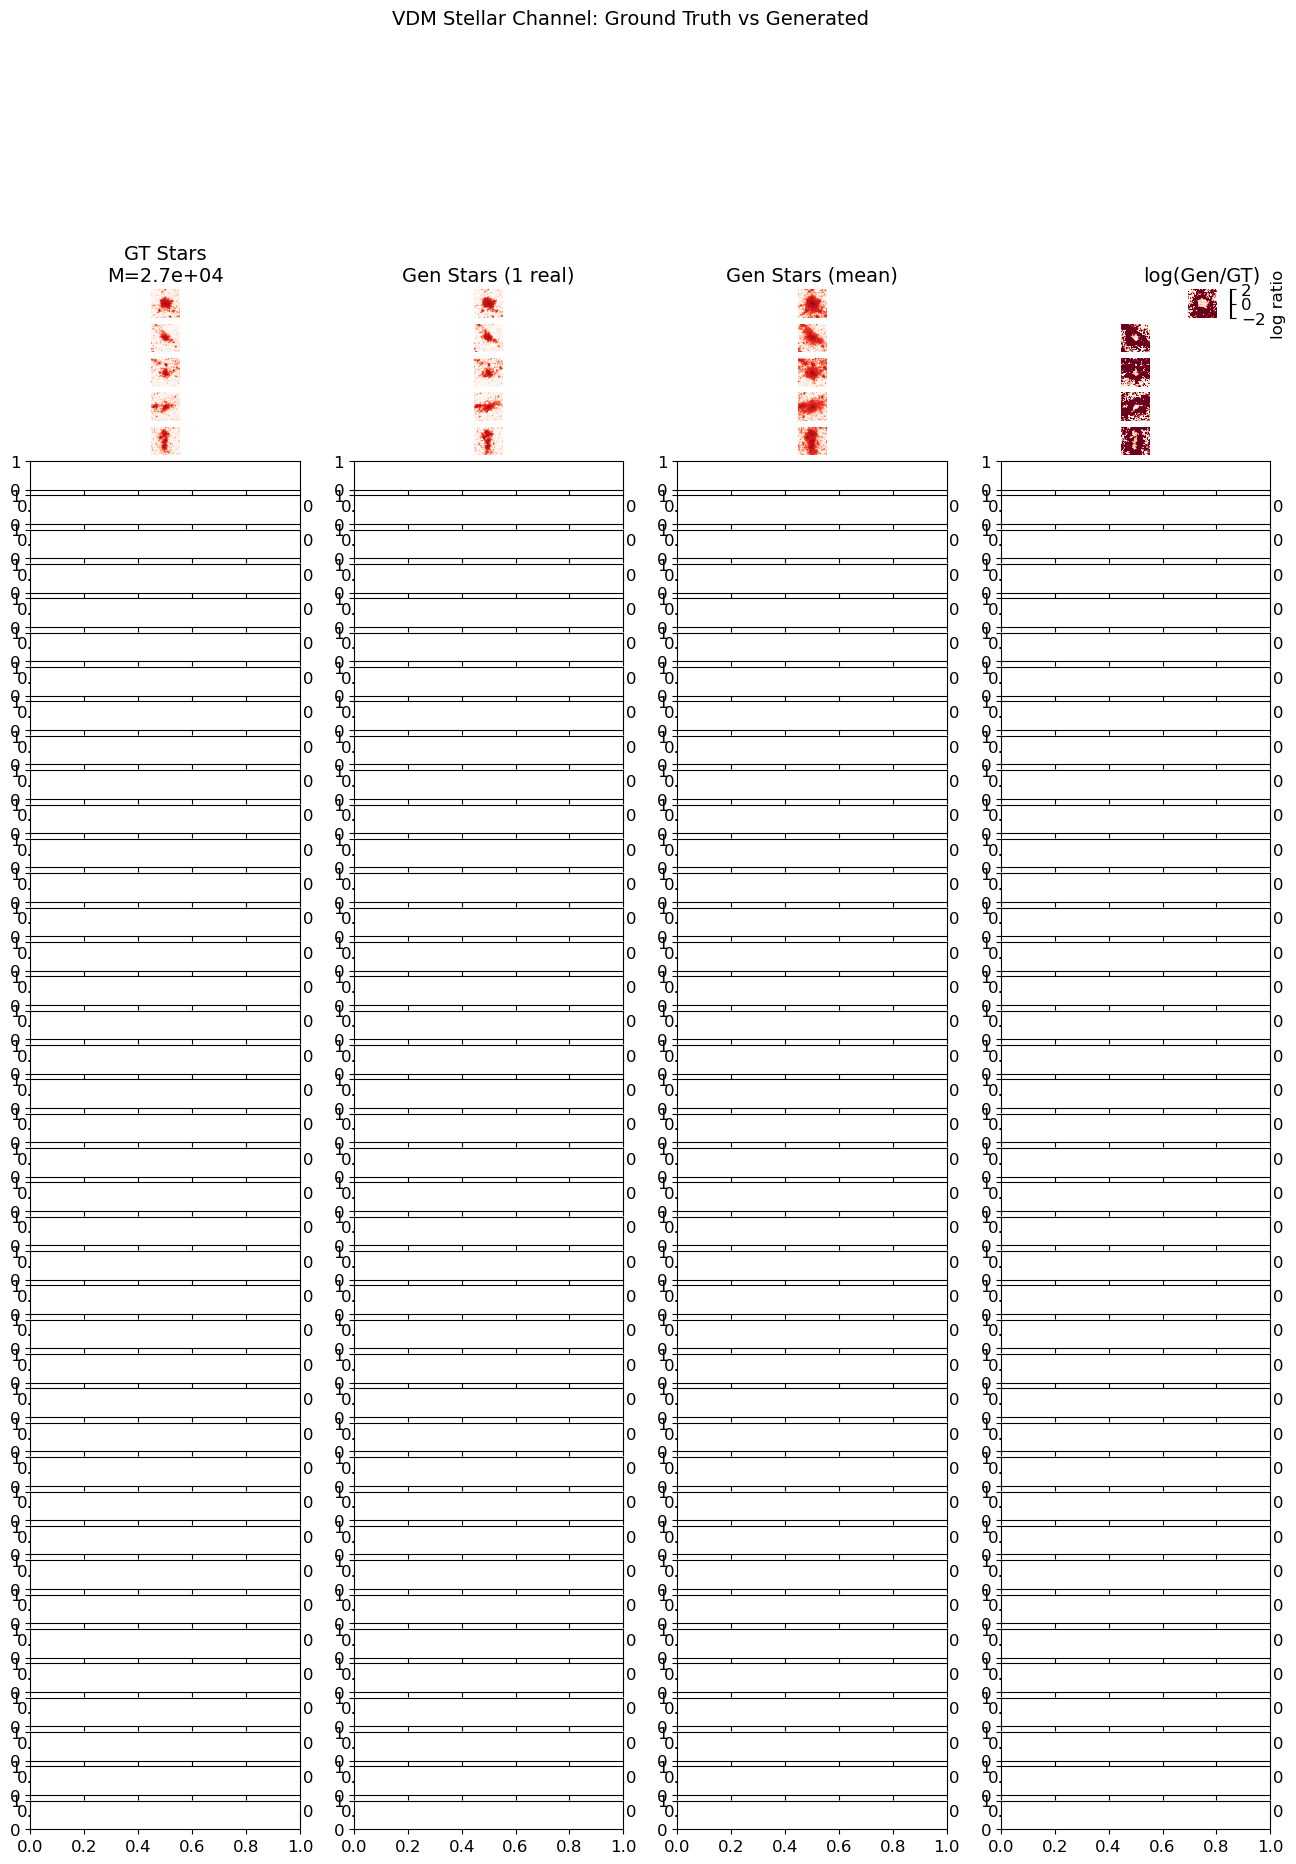

In [25]:
# Visual comparison: Ground Truth vs Generated (Stars)
fig, axes = plt.subplots(n_examples, 4, figsize=(16, 4*5))

for i in range(5):
    gt = gt_stars_cutouts[i]
    gen_mean = gen_stars[:, i].mean(axis=0)
    gen_single = gen_stars[0, i]
    
    # Common colorscale
    vmin = 1e-3
    vmax = max(gt.max(), gen_mean.max())
    
    # Ground Truth
    ax = axes[i, 0]
    im = ax.imshow(np.log10(gt + vmin), cmap='Reds', vmin=np.log10(vmin), vmax=np.log10(vmax))
    ax.set_title(f'GT Stars\nM={halo_info[i]["mass"]:.1e}' if i == 0 else '')
    ax.set_ylabel(f'Halo {i+1}')
    ax.axis('off')
    
    # Generated (single realization)
    ax = axes[i, 1]
    ax.imshow(np.log10(gen_single + vmin), cmap='Reds', vmin=np.log10(vmin), vmax=np.log10(vmax))
    ax.set_title('Gen Stars (1 real)' if i == 0 else '')
    ax.axis('off')
    
    # Generated (mean)
    ax = axes[i, 2]
    ax.imshow(np.log10(gen_mean + vmin), cmap='Reds', vmin=np.log10(vmin), vmax=np.log10(vmax))
    ax.set_title('Gen Stars (mean)' if i == 0 else '')
    ax.axis('off')
    
    # Difference (log scale)
    ax = axes[i, 3]
    diff = np.log10(gen_mean + vmin) - np.log10(gt + vmin)
    im = ax.imshow(diff, cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_title('log(Gen/GT)' if i == 0 else '')
    ax.axis('off')
    if i == 0:
        plt.colorbar(im, ax=ax, label='log ratio')

plt.suptitle('VDM Stellar Channel: Ground Truth vs Generated', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.1 Sparsity Analysis: GT vs Generated

One of the key issues is that diffusion models produce smooth outputs while stellar fields are sparse.

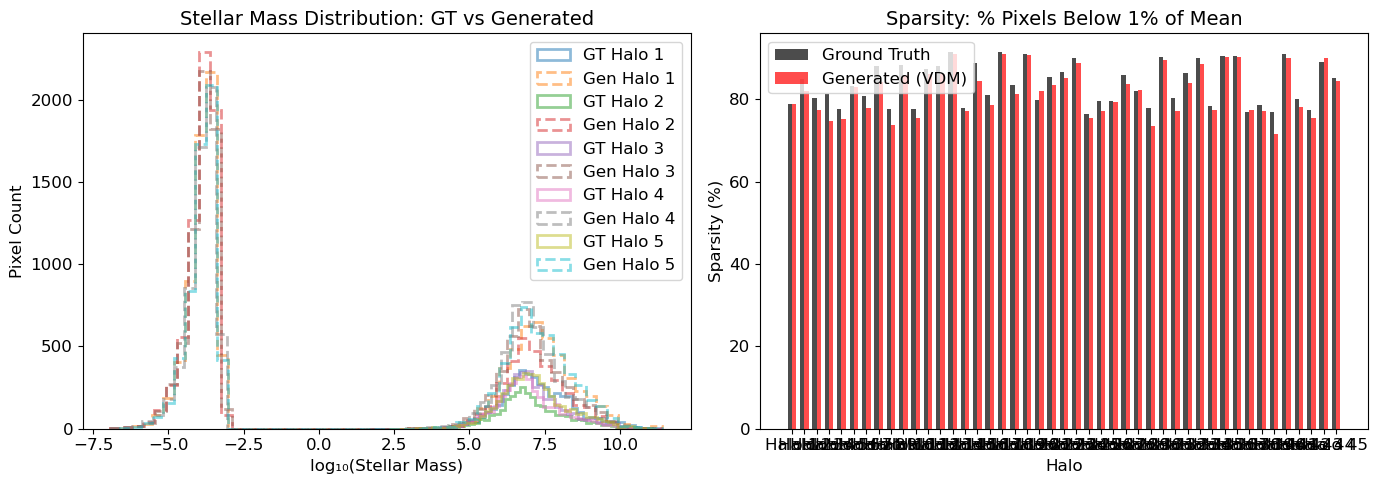


📊 SPARSITY ANALYSIS:
Halo       GT Sparsity     Gen Sparsity    Difference     
-------------------------------------------------------
Halo 1     78.9            78.7            -0.1%
Halo 2     84.9            82.0            -2.9%
Halo 3     80.4            77.4            -3.0%
Halo 4     81.3            74.6            -6.6%
Halo 5     77.7            75.1            -2.6%
Halo 6     83.2            82.9            -0.3%
Halo 7     80.7            77.9            -2.8%
Halo 8     88.0            84.2            -3.8%
Halo 9     77.5            73.8            -3.8%
Halo 10    88.2            85.8            -2.4%
Halo 11    77.6            75.4            -2.2%
Halo 12    87.2            86.2            -1.1%
Halo 13    88.1            86.2            -2.0%
Halo 14    91.3            90.9            -0.4%
Halo 15    77.8            77.1            -0.6%
Halo 16    88.8            84.5            -4.3%
Halo 17    81.1            78.6            -2.5%
Halo 18    91.4            90.

In [26]:
# Sparsity comparison for stellar channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax = axes[0]
for i in range(5):
    gt_flat = gt_stars_cutouts[i].flatten()
    gen_flat = gen_stars[0, i].flatten()
    
    # Only plot positive values
    gt_pos = gt_flat[gt_flat > 0]
    gen_pos = gen_flat[gen_flat > 0]
    
    if len(gt_pos) > 0:
        ax.hist(np.log10(gt_pos), bins=50, alpha=0.5, label=f'GT Halo {i+1}', histtype='step', linewidth=2)
    if len(gen_pos) > 0:
        ax.hist(np.log10(gen_pos), bins=50, alpha=0.5, label=f'Gen Halo {i+1}', histtype='step', linewidth=2, linestyle='--')

ax.set_xlabel('log₁₀(Stellar Mass)')
ax.set_ylabel('Pixel Count')
ax.set_title('Stellar Mass Distribution: GT vs Generated')
ax.legend()

# Sparsity bar chart
ax = axes[1]
gt_sparsities = []
gen_sparsities = []

for i in range(n_examples):
    gt_flat = gt_stars_cutouts[i].flatten()
    gen_flat = gen_stars[0, i].flatten()
    
    # Define "zero" threshold (below 1% of mean)
    threshold_gt = gt_flat.mean() * 0.01
    threshold_gen = gen_flat.mean() * 0.01
    
    gt_sparsities.append((gt_flat < threshold_gt).sum() / len(gt_flat) * 100)
    gen_sparsities.append((gen_flat < threshold_gen).sum() / len(gen_flat) * 100)

x = np.arange(n_examples)
width = 0.35
ax.bar(x - width/2, gt_sparsities, width, label='Ground Truth', color='black', alpha=0.7)
ax.bar(x + width/2, gen_sparsities, width, label='Generated (VDM)', color='red', alpha=0.7)
ax.set_xlabel('Halo')
ax.set_ylabel('Sparsity (%)')
ax.set_title('Sparsity: % Pixels Below 1% of Mean')
ax.set_xticks(x)
ax.set_xticklabels([f'Halo {i+1}' for i in range(n_examples)])
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 SPARSITY ANALYSIS:")
print(f"{'Halo':<10} {'GT Sparsity':<15} {'Gen Sparsity':<15} {'Difference':<15}")
print("-" * 55)
for i in range(n_examples):
    diff = gen_sparsities[i] - gt_sparsities[i]
    print(f"Halo {i+1:<5} {gt_sparsities[i]:<15.1f} {gen_sparsities[i]:<15.1f} {diff:+.1f}%")

print(f"\n→ Generated fields are {'MORE' if np.mean(gen_sparsities) > np.mean(gt_sparsities) else 'LESS'} sparse than GT")

### 3.2 Power Spectrum Analysis: Stellar Channel

The power spectrum reveals structure at different scales. Stars have more power at small scales (high k) due to point sources.


Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of t

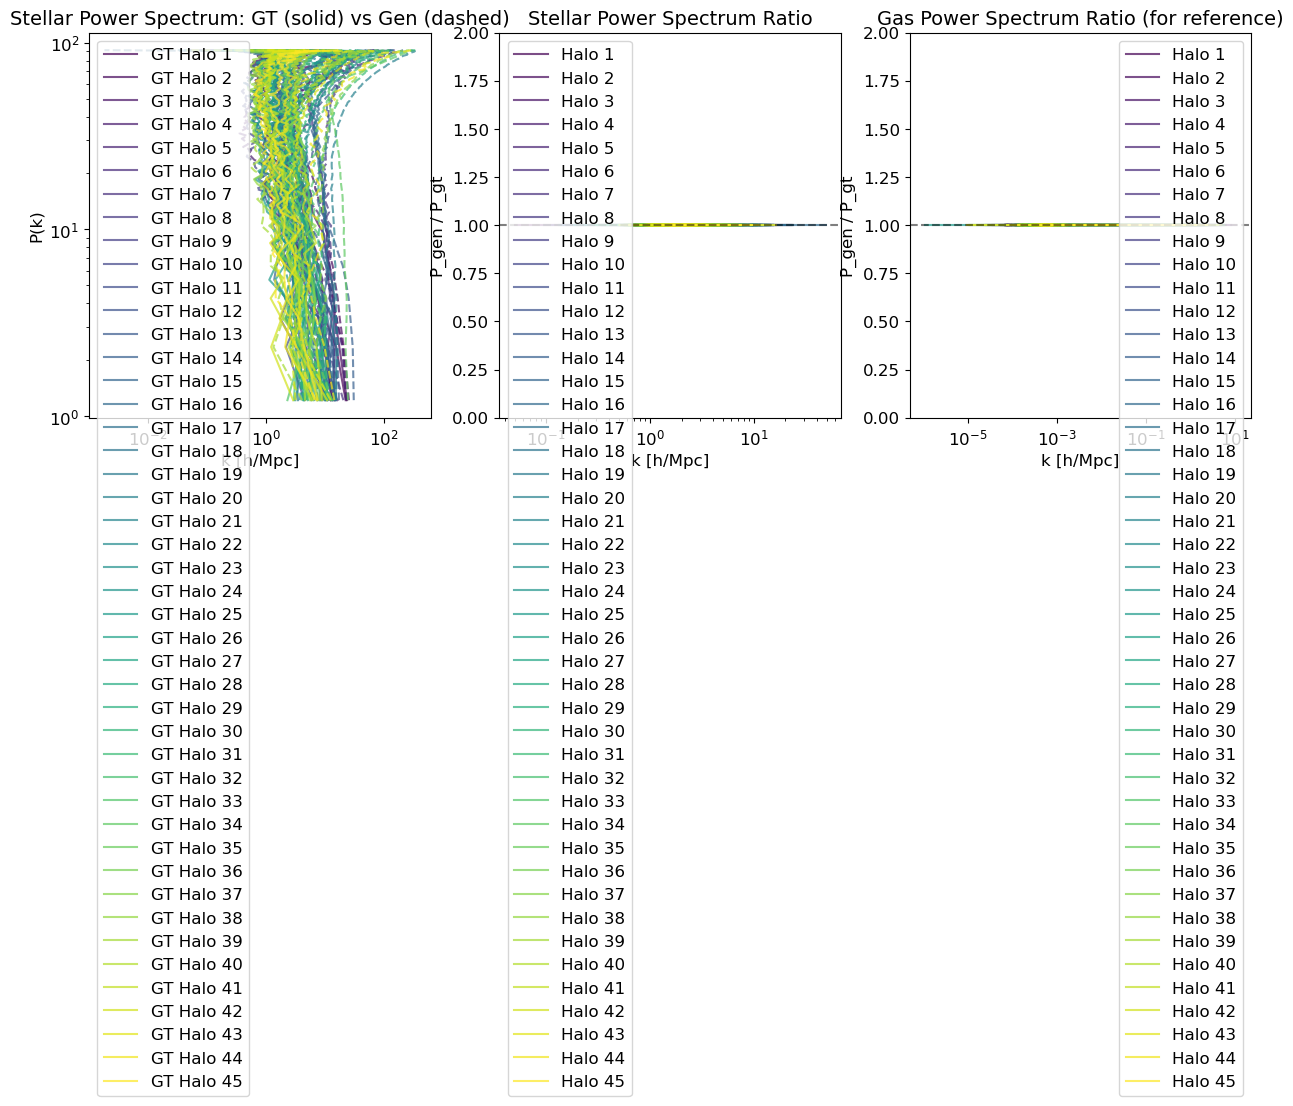

In [28]:
# Power spectrum comparison for stellar fields
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Compute power spectra for each halo
colors = plt.cm.viridis(np.linspace(0, 1, n_examples))

ax = axes[0]
for i in range(n_examples):
    gt = gt_stars_cutouts[i]
    gen = gen_stars[0, i]
    
    # Compute power spectra
    k_gt, pk_gt = compute_power_spectrum_simple(gt, BoxSize=CUTOUT_SIZE_MPC, MAS='CIC')
    k_gen, pk_gen = compute_power_spectrum_simple(gen, BoxSize=CUTOUT_SIZE_MPC, MAS='CIC')
    
    ax.loglog(k_gt, pk_gt, '-', color=colors[i], alpha=0.7, label=f'GT Halo {i+1}')
    ax.loglog(k_gen, pk_gen, '--', color=colors[i], alpha=0.7)

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P(k)')
ax.set_title('Stellar Power Spectrum: GT (solid) vs Gen (dashed)')
ax.legend()

# Ratio P_gen / P_gt
ax = axes[1]
for i in range(n_examples):
    gt = gt_stars_cutouts[i]
    gen = gen_stars[0, i]
    
    k_gt, pk_gt = compute_power_spectrum_simple(gt, BoxSize=CUTOUT_SIZE_MPC, MAS='CIC')
    k_gen, pk_gen = compute_power_spectrum_simple(gen, BoxSize=CUTOUT_SIZE_MPC, MAS='CIC')
    
    # Interpolate to common k
    ratio = pk_gen / pk_gt
    ax.semilogx(k_gt, ratio, '-', color=colors[i], alpha=0.7, label=f'Halo {i+1}')

ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P_gen / P_gt')
ax.set_title('Stellar Power Spectrum Ratio')
ax.set_ylim(0, 2)
ax.legend()

# Gas comparison (for reference)
ax = axes[2]
for i in range(n_examples):
    gt = gt_gas_cutouts[i]
    gen = gen_gas[0, i]
    
    k_gt, pk_gt = compute_power_spectrum_simple(gt, BoxSize=CUTOUT_SIZE_MPC, MAS='CIC')
    k_gen, pk_gen = compute_power_spectrum_simple(gen, BoxSize=CUTOUT_SIZE_MPC, MAS='CIC')
    
    ratio = pk_gen / pk_gt
    ax.semilogx(k_gt, ratio, '-', color=colors[i], alpha=0.7, label=f'Halo {i+1}')

ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P_gen / P_gt')
ax.set_title('Gas Power Spectrum Ratio (for reference)')
ax.set_ylim(0, 2)
ax.legend()

plt.tight_layout()
plt.show()

### 3.3 Radial Profile Analysis

Another way to compare: average radial profile from halo center.

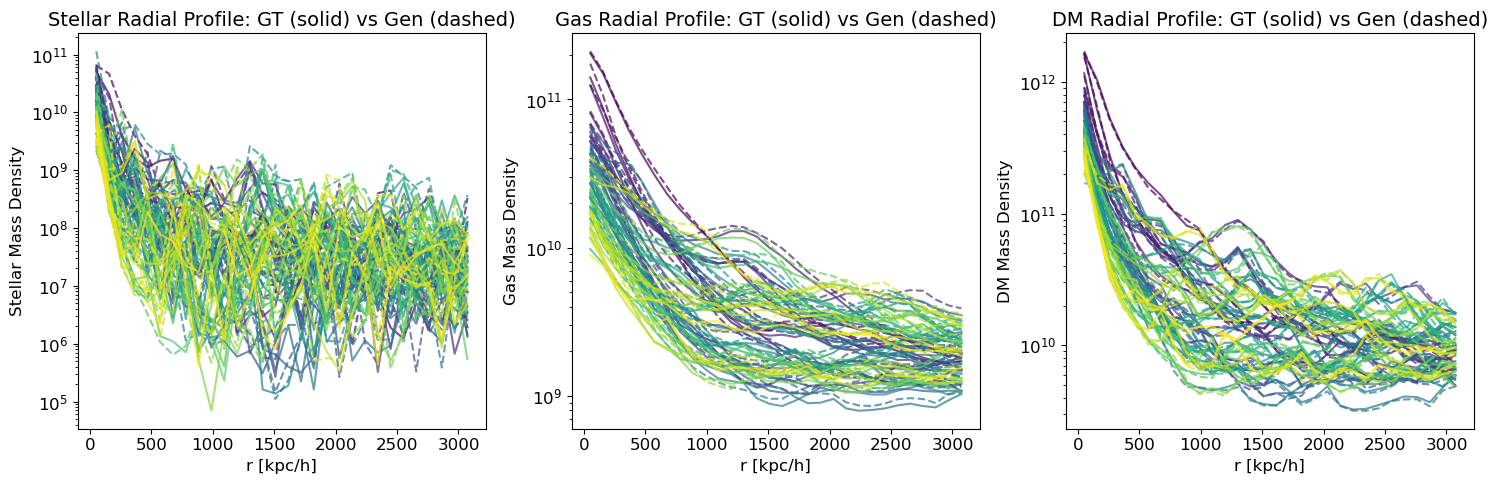

In [31]:
def compute_radial_profile(field, n_bins=30):
    """Compute azimuthally averaged radial profile from center."""
    center = np.array(field.shape) // 2
    y, x = np.ogrid[:field.shape[0], :field.shape[1]]
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    
    r_max = min(center)
    r_bins = np.linspace(0, r_max, n_bins + 1)
    r_mid = (r_bins[:-1] + r_bins[1:]) / 2
    
    profile = []
    for i in range(n_bins):
        mask = (r >= r_bins[i]) & (r < r_bins[i+1])
        if mask.any():
            profile.append(field[mask].mean())
        else:
            profile.append(np.nan)
    
    return r_mid, np.array(profile)

# Radial profile comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Get cutout size in pixels from generated data
cutout_pix = gt_stars_cutouts[0].shape[0]
pix_to_kpc = CUTOUT_SIZE_MPC * 1000 / cutout_pix  # kpc per pixel

# Stars
ax = axes[0]
for i in range(n_examples):
    r_gt, prof_gt = compute_radial_profile(gt_stars_cutouts[i])
    r_gen, prof_gen = compute_radial_profile(gen_stars[0, i])
    
    r_kpc = r_gt * pix_to_kpc
    ax.semilogy(r_kpc, prof_gt, '-', color=colors[i], alpha=0.7, label=f'GT Halo {i+1}')
    ax.semilogy(r_kpc, prof_gen, '--', color=colors[i], alpha=0.7)

ax.set_xlabel('r [kpc/h]')
ax.set_ylabel('Stellar Mass Density')
ax.set_title('Stellar Radial Profile: GT (solid) vs Gen (dashed)')
# ax.legend()

# Gas
ax = axes[1]
for i in range(n_examples):
    r_gt, prof_gt = compute_radial_profile(gt_gas_cutouts[i])
    r_gen, prof_gen = compute_radial_profile(gen_gas[0, i])
    
    r_kpc = r_gt * pix_to_kpc
    ax.semilogy(r_kpc, prof_gt, '-', color=colors[i], alpha=0.7, label=f'GT Halo {i+1}')
    ax.semilogy(r_kpc, prof_gen, '--', color=colors[i], alpha=0.7)

ax.set_xlabel('r [kpc/h]')
ax.set_ylabel('Gas Mass Density')
ax.set_title('Gas Radial Profile: GT (solid) vs Gen (dashed)')
# ax.legend()

# DM
ax = axes[2]
for i in range(n_examples):
    r_gt, prof_gt = compute_radial_profile(gt_dm_cutouts[i])
    r_gen, prof_gen = compute_radial_profile(gen_dm[0, i])
    
    r_kpc = r_gt * pix_to_kpc
    ax.semilogy(r_kpc, prof_gt, '-', color=colors[i], alpha=0.7, label=f'GT Halo {i+1}')
    ax.semilogy(r_kpc, prof_gen, '--', color=colors[i], alpha=0.7)

ax.set_xlabel('r [kpc/h]')
ax.set_ylabel('DM Mass Density')
ax.set_title('DM Radial Profile: GT (solid) vs Gen (dashed)')
# ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Central Region Mass Analysis

The majority of stellar mass is concentrated in the central few pixels. Let's analyze how well the model captures this central mass.

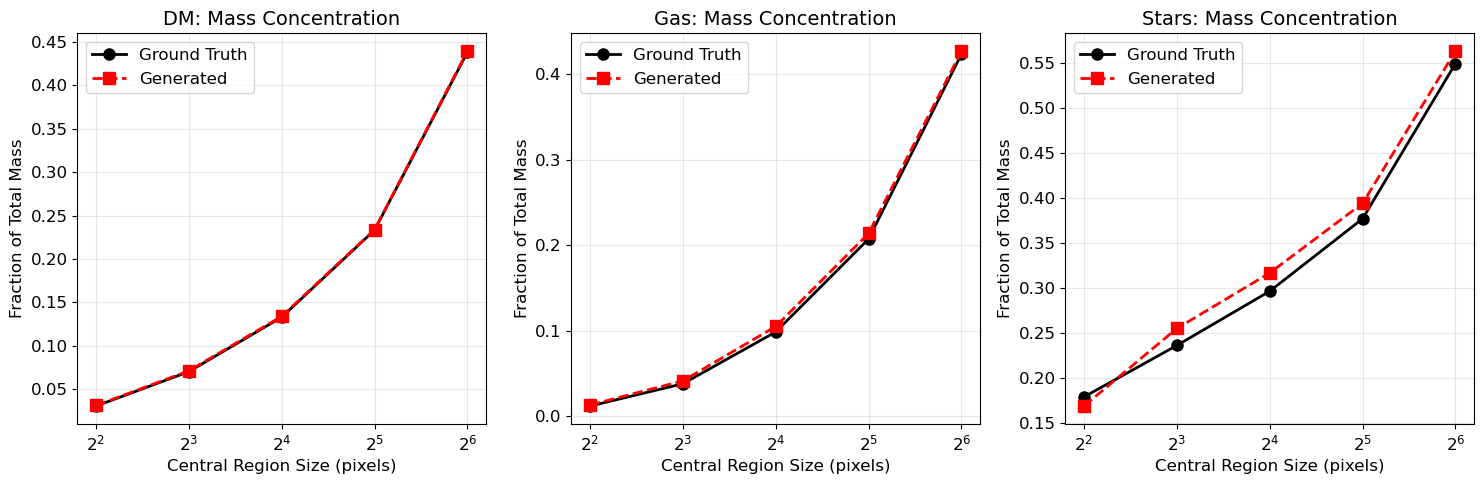


Central Mass Capture Analysis


In [32]:
# Central region mass analysis
# The cutouts are 128x128 pixels, centered on halos
# Central 4 pixels = 2x2 region at center (pixels 63:65, 63:65)
# Let's also look at larger central regions: 4x4, 8x8, 16x16

center = cutout_pix // 2  # 64

central_sizes = [2, 4, 8, 16, 32]  # Half-widths of central regions

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
channels = ['DM', 'Gas', 'Stars']
gt_data = [gt_dm_cutouts, gt_gas_cutouts, gt_stars_cutouts]
gen_data = [gen_dm, gen_gas, gen_stars]

for ax, ch_name, gt_ch, gen_ch in zip(axes, channels, gt_data, gen_data):
    # Average over realizations for generated
    gen_mean = gen_ch.mean(axis=0)  # (n_halos, 128, 128)
    
    gt_central_fracs = []
    gen_central_fracs = []
    gt_central_masses = []
    gen_central_masses = []
    
    for half_size in central_sizes:
        lo = center - half_size
        hi = center + half_size
        
        # Extract central region
        gt_central = gt_ch[:, lo:hi, lo:hi]  # (n_halos, size, size)
        gen_central = gen_mean[:, lo:hi, lo:hi]
        
        # Sum mass in central region
        gt_mass_central = gt_central.sum(axis=(1, 2))
        gen_mass_central = gen_central.sum(axis=(1, 2))
        
        # Total mass in cutout
        gt_mass_total = gt_ch.sum(axis=(1, 2))
        gen_mass_total = gen_mean.sum(axis=(1, 2))
        
        # Fraction of mass in central region
        gt_frac = gt_mass_central / (gt_mass_total + 1e-10)
        gen_frac = gen_mass_central / (gen_mass_total + 1e-10)
        
        gt_central_fracs.append(gt_frac.mean())
        gen_central_fracs.append(gen_frac.mean())
        gt_central_masses.append(gt_mass_central.mean())
        gen_central_masses.append(gen_mass_central.mean())
    
    # Plot fraction of total mass in central region vs region size
    region_sizes = [2*s for s in central_sizes]  # Full size (diameter)
    ax.plot(region_sizes, gt_central_fracs, 'ko-', label='Ground Truth', lw=2, ms=8)
    ax.plot(region_sizes, gen_central_fracs, 'rs--', label='Generated', lw=2, ms=8)
    ax.set_xlabel('Central Region Size (pixels)')
    ax.set_ylabel('Fraction of Total Mass')
    ax.set_title(f'{ch_name}: Mass Concentration')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log', base=2)

plt.tight_layout()
plt.savefig('stellar_central_mass_fraction.png', dpi=150)
plt.show()

print("\n" + "="*80)
print("Central Mass Capture Analysis")
print("="*80)

In [33]:
# Detailed central 4-pixel (2x2) analysis
center = cutout_pix // 2
half_size = 1  # For 2x2 central region
lo, hi = center - half_size, center + half_size

print("="*80)
print("CENTRAL 2x2 PIXEL MASS ANALYSIS (pixels 63:65)")
print("="*80)

for ch_name, gt_ch, gen_ch in zip(['DM', 'Gas', 'Stars'], 
                                   [gt_dm_cutouts, gt_gas_cutouts, gt_stars_cutouts],
                                   [gen_dm, gen_gas, gen_stars]):
    print(f"\n{ch_name} Channel:")
    print("-" * 40)
    
    # Ground truth central mass
    gt_central = gt_ch[:, lo:hi, lo:hi].sum(axis=(1, 2))
    gt_total = gt_ch.sum(axis=(1, 2))
    gt_frac = gt_central / (gt_total + 1e-10)
    
    print(f"  GT central mass:    {gt_central.mean():.4f} ± {gt_central.std():.4f}")
    print(f"  GT total mass:      {gt_total.mean():.4f} ± {gt_total.std():.4f}")
    print(f"  GT central fraction: {gt_frac.mean()*100:.1f}% ± {gt_frac.std()*100:.1f}%")
    
    # Generated (per realization)
    for r in range(gen_ch.shape[0]):
        gen_r = gen_ch[r]  # (n_halos, 128, 128)
        gen_central = gen_r[:, lo:hi, lo:hi].sum(axis=(1, 2))
        gen_total = gen_r.sum(axis=(1, 2))
        gen_frac = gen_central / (gen_total + 1e-10)
        
        # Mass ratio (gen/gt) in central region
        mass_ratio = gen_central / (gt_central + 1e-10)
        
        print(f"  Gen r{r} central mass: {gen_central.mean():.4f} ± {gen_central.std():.4f}")
        print(f"  Gen r{r} central frac: {gen_frac.mean()*100:.1f}% ± {gen_frac.std()*100:.1f}%")
        print(f"  Gen/GT ratio:        {mass_ratio.mean():.3f} ± {mass_ratio.std():.3f}")

CENTRAL 2x2 PIXEL MASS ANALYSIS (pixels 63:65)

DM Channel:
----------------------------------------
  GT central mass:    2038200401920.0000 ± 1538148401152.0000
  GT total mass:      252474736771072.0000 ± 106313015099392.0000
  GT central fraction: 0.9% ± 0.6%
  Gen r0 central mass: 2023973453824.0000 ± 1474215542784.0000
  Gen r0 central frac: 0.9% ± 0.5%
  Gen/GT ratio:        1.049 ± 0.320
  Gen r1 central mass: 2061452443648.0000 ± 1503208407040.0000
  Gen r1 central frac: 0.9% ± 0.6%
  Gen/GT ratio:        1.101 ± 0.413
  Gen r2 central mass: 1997275922432.0000 ± 1384329379840.0000
  Gen r2 central frac: 0.9% ± 0.5%
  Gen/GT ratio:        1.068 ± 0.380
  Gen r3 central mass: 2065312382976.0000 ± 1571354181632.0000
  Gen r3 central frac: 0.9% ± 0.6%
  Gen/GT ratio:        1.082 ± 0.359
  Gen r4 central mass: 2067003867136.0000 ± 1780285440000.0000
  Gen r4 central frac: 0.9% ± 0.6%
  Gen/GT ratio:        1.043 ± 0.359
  Gen r5 central mass: 1993163145216.0000 ± 1402930069504.000

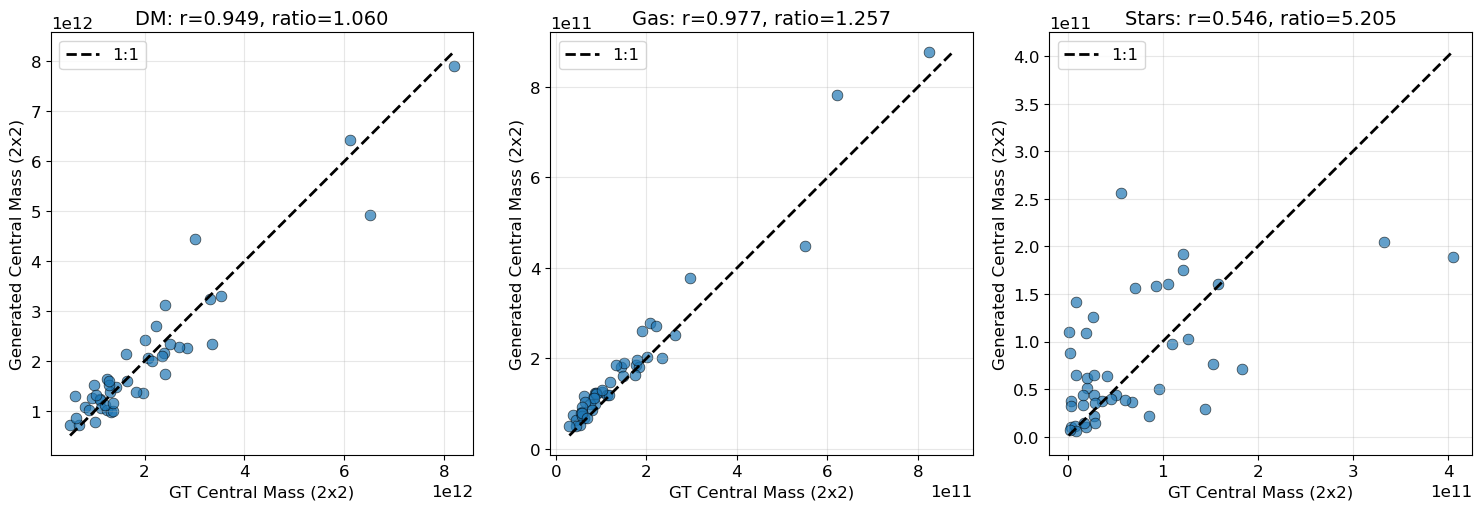

In [34]:
# Scatter plot: GT central mass vs Generated central mass per halo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

center = cutout_pix // 2
half_size = 1  # 2x2 central region
lo, hi = center - half_size, center + half_size

for ax, ch_name, gt_ch, gen_ch in zip(axes, 
                                       ['DM', 'Gas', 'Stars'],
                                       [gt_dm_cutouts, gt_gas_cutouts, gt_stars_cutouts],
                                       [gen_dm, gen_gas, gen_stars]):
    # GT central mass per halo
    gt_central = gt_ch[:, lo:hi, lo:hi].sum(axis=(1, 2))
    
    # Generated central mass (mean over realizations)
    gen_mean = gen_ch.mean(axis=0)
    gen_central = gen_mean[:, lo:hi, lo:hi].sum(axis=(1, 2))
    
    # Scatter plot
    ax.scatter(gt_central, gen_central, alpha=0.7, s=60, edgecolors='k', linewidths=0.5)
    
    # 1:1 line
    max_val = max(gt_central.max(), gen_central.max())
    min_val = min(gt_central.min(), gen_central.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='1:1')
    
    # Correlation coefficient
    corr = np.corrcoef(gt_central, gen_central)[0, 1]
    
    # Mean ratio
    ratio = (gen_central / (gt_central + 1e-10)).mean()
    
    ax.set_xlabel('GT Central Mass (2x2)')
    ax.set_ylabel('Generated Central Mass (2x2)')
    ax.set_title(f'{ch_name}: r={corr:.3f}, ratio={ratio:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('stellar_central_mass_scatter.png', dpi=150)
plt.show()

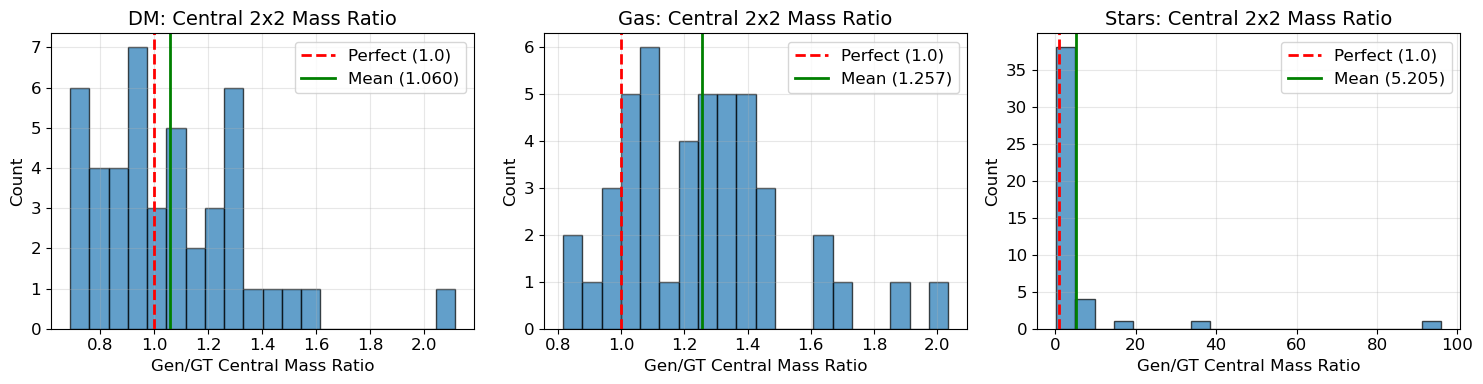


Central 2x2 Mass Ratio Summary (Gen/GT):
--------------------------------------------------
DM    : mean=1.060, std=0.277, median=1.001, min=0.689, max=2.116
Gas   : mean=1.257, std=0.250, median=1.249, min=0.817, max=2.035
Stars : mean=5.205, std=14.846, median=1.454, min=0.197, max=95.946


In [35]:
# Histogram of central mass ratios (Generated/GT) for each channel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

center = cutout_pix // 2
half_size = 1
lo, hi = center - half_size, center + half_size

for ax, ch_name, gt_ch, gen_ch in zip(axes, 
                                       ['DM', 'Gas', 'Stars'],
                                       [gt_dm_cutouts, gt_gas_cutouts, gt_stars_cutouts],
                                       [gen_dm, gen_gas, gen_stars]):
    gt_central = gt_ch[:, lo:hi, lo:hi].sum(axis=(1, 2))
    gen_mean = gen_ch.mean(axis=0)
    gen_central = gen_mean[:, lo:hi, lo:hi].sum(axis=(1, 2))
    
    # Ratio per halo
    ratio = gen_central / (gt_central + 1e-10)
    
    ax.hist(ratio, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(1.0, color='r', linestyle='--', lw=2, label='Perfect (1.0)')
    ax.axvline(ratio.mean(), color='g', linestyle='-', lw=2, label=f'Mean ({ratio.mean():.3f})')
    ax.set_xlabel('Gen/GT Central Mass Ratio')
    ax.set_ylabel('Count')
    ax.set_title(f'{ch_name}: Central 2x2 Mass Ratio')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stellar_central_mass_ratio_hist.png', dpi=150)
plt.show()

# Summary statistics
print("\nCentral 2x2 Mass Ratio Summary (Gen/GT):")
print("-" * 50)
for ch_name, gt_ch, gen_ch in zip(['DM', 'Gas', 'Stars'],
                                   [gt_dm_cutouts, gt_gas_cutouts, gt_stars_cutouts],
                                   [gen_dm, gen_gas, gen_stars]):
    gt_central = gt_ch[:, lo:hi, lo:hi].sum(axis=(1, 2))
    gen_mean = gen_ch.mean(axis=0)
    gen_central = gen_mean[:, lo:hi, lo:hi].sum(axis=(1, 2))
    ratio = gen_central / (gt_central + 1e-10)
    
    print(f"{ch_name:6s}: mean={ratio.mean():.3f}, std={ratio.std():.3f}, "
          f"median={np.median(ratio):.3f}, min={ratio.min():.3f}, max={ratio.max():.3f}")

## Part 4: Why VDM Works Better Than Interpolant

Now let's understand the fundamental differences between VDM and Interpolant models.

### Key Architectural Differences

| Feature | VDM | Interpolant |
|---------|-----|-------------|
| **What it learns** | Noise ε added to x | Velocity v = dx/dt |
| **Formulation** | z_t = α_t x + σ_t ε | x_t = (1-t)x_0 + t·x_1 |
| **Noise schedule** | Learned (γ_min to γ_max) | None (linear interp) |
| **Loss function** | Weighted MSE + focal loss | Simple MSE |
| **Sampling** | Ancestral (stochastic) | ODE integration (deterministic) |
| **Starting point** | Pure noise N(0,1) | x_0 = DMO condition |

### Why VDM May Work Better

1. **Stochastic sampling**: VDM samples from pure noise → data, with noise injection at each step. This can help explore more diverse outputs.

2. **Learned noise schedule**: VDM's `learned_nn` schedule adapts to the data distribution, potentially allocating more capacity to difficult regions.

3. **Focal loss for stars**: VDM explicitly upweights hard-to-predict stellar regions.

4. **Starting point**: Interpolant starts from `x_0 = dm_copy`, which may bias the output toward the DMO structure.